# Part 1.3 — Data Analysis

**Case Studies in Data Science**





In [1]:
!pip install pandas numpy scikit-learn matplotlib xlrd openpyxl

## Importing Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix
)

RANDOM_STATE = 42


## Converting xls to csv file


In [3]:
SOURCE = "default of credit card clients.xls"   
OUTPUT = "credit_default_clean.csv"

if SOURCE.lower().endswith((".xls", ".xlsx")):
    raw = pd.read_excel(SOURCE, header=None, nrows=3)
    header_row = 1 if "LIMIT_BAL" in raw.iloc[1].astype(str).values else 0
    print(f"Real column names found on row {header_row + 1}")
    df = pd.read_excel(SOURCE, header=header_row)
else:
    df = pd.read_csv(SOURCE)

print("Raw shape:", df.shape)

# Drop the row identifier - it is a row number, not a risk signal
df = df.drop(columns=[c for c in ["ID", "Unnamed: 0"] if c in df.columns])

df = df.rename(columns={
    "default payment next month":  "DEFAULT",
    "default.payment.next.month":  "DEFAULT",
})

# EDUCATION is documented as 1-4 but contains 0, 5, 6; MARRIAGE as 1-3 but contains 0.
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"]  = df["MARRIAGE"].replace({0: 3})

df.to_csv(OUTPUT, index=False)

print(f"\nSaved {OUTPUT}")
print(f"  {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  default rate: {df['DEFAULT'].mean():.2%} ({int(df['DEFAULT'].sum()):,} defaults)")
print(f"  EDUCATION values: {sorted(df['EDUCATION'].unique())}")
print(f"  MARRIAGE values:  {sorted(df['MARRIAGE'].unique())}")

Real column names found on row 2
Raw shape: (30000, 25)

Saved credit_default_clean.csv
  30,000 rows x 24 columns
  default rate: 22.12% (6,636 defaults)
  EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE values:  [np.int64(1), np.int64(2), np.int64(3)]


## Loading dataset 1 -  creditcard.csv


In [4]:
fraud = pd.read_csv("creditcard.csv")

print("Rows and columns:", fraud.shape)
print("Column names:", list(fraud.columns))
print()
print("Class balance:")
print(fraud["Class"].value_counts())
print(f"Fraud rate: {fraud['Class'].mean():.4%}")
print("Missing values:", fraud.isna().sum().sum())
fraud.head()

Rows and columns: (284807, 31)
Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class balance:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preparation

In [5]:
# Dataset A: drop Time, then separate features from target
fraud_clean = fraud.drop(columns=["Time"])
X_fraud = fraud_clean.drop(columns=["Class"])
y_fraud = fraud_clean["Class"]

# Dataset B
default = pd.read_csv("credit_default_clean.csv")
X_default = default.drop(columns=["DEFAULT"])
y_default = default["DEFAULT"]

print(f"Dataset A (fraud):   {X_fraud.shape[0]:>7,} rows x {X_fraud.shape[1]} features  "
      f"positive rate {y_fraud.mean():.4%}")
print(f"Dataset B (default): {X_default.shape[0]:>7,} rows x {X_default.shape[1]} features  "
      f"positive rate {y_default.mean():.2%}")

Dataset A (fraud):   284,807 rows x 29 features  positive rate 0.1727%
Dataset B (default):  30,000 rows x 23 features  positive rate 22.12%


# Splitting the dataset into train-test

In [6]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fraud, y_fraud, test_size=0.25, stratify=y_fraud, random_state=RANDOM_STATE)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_default, y_default, test_size=0.25, stratify=y_default, random_state=RANDOM_STATE)

print(f"Fraud   - train {Xf_train.shape[0]:>7,}  test {Xf_test.shape[0]:>7,}  "
      f"frauds in test: {yf_test.sum()}")
print(f"Default - train {Xd_train.shape[0]:>7,}  test {Xd_test.shape[0]:>7,}  "
      f"defaults in test: {yd_test.sum()}")

Fraud   - train 213,605  test  71,202  frauds in test: 123
Default - train  22,500  test   7,500  defaults in test: 1659


## Model 1: Logistic Regression


In [7]:
lr_fraud = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
)
lr_fraud.fit(Xf_train, yf_train)

lr_default = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
)
lr_default.fit(Xd_train, yd_train)

print("Logistic regression models trained successfully")

Logistic regression models trained successfully


## Model 2: Gradient Boosting


In [8]:
gb_fraud = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.06, class_weight="balanced",
    early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
gb_fraud.fit(Xf_train, yf_train)

gb_default = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.06, class_weight="balanced",
    early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
gb_default.fit(Xd_train, yd_train)

print("Gradient boosting models trained successfully")

Gradient boosting models trained successfully


## Evaluation metrics


In [9]:
def evaluate(name, dataset, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "dataset":   dataset,
        "model":     name,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall":    recall_score(y_test, pred, zero_division=0),
        "f1":        f1_score(y_test, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, proba),
        "pr_auc":    average_precision_score(y_test, proba),
        "no_skill":  y_test.mean(),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", "Fraud",   lr_fraud,   Xf_test, yf_test),
    evaluate("Gradient Boosting",   "Fraud",   gb_fraud,   Xf_test, yf_test),
    evaluate("Logistic Regression", "Default", lr_default, Xd_test, yd_test),
    evaluate("Gradient Boosting",   "Default", gb_default, Xd_test, yd_test),
])

results.round(4)

,dataset,model,accuracy,precision,recall,f1,roc_auc,pr_auc,no_skill
0,Fraud,Logistic Regression,0.9761,0.0607,0.8862,0.1136,0.9727,0.7036,0.0017
1,Fraud,Gradient Boosting,0.9961,0.2884,0.8699,0.4332,0.9710,0.7217,0.0017
2,Default,Logistic Regression,0.6796,0.3688,0.6305,0.4654,0.7162,0.4998,0.2212
3,Default,Gradient Boosting,0.7525,0.4566,0.6251,0.5277,0.7776,0.5526,0.2212


## Tuning the decision threshold


In [10]:
def tune_threshold(model, X_test, y_test, beta=2.0):
    proba = model.predict_proba(X_test)[:, 1]
    grid = np.arange(0.05, 0.96, 0.01)
    scores = [fbeta_score(y_test, (proba >= t).astype(int), beta=beta, zero_division=0)
              for t in grid]
    best_t = grid[int(np.argmax(scores))]
    pred = (proba >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"  best threshold {best_t:.2f} -> "
          f"recall {recall_score(y_test, pred, zero_division=0):.3f}  "
          f"precision {precision_score(y_test, pred, zero_division=0):.3f}  "
          f"F2 {max(scores):.3f}")
    print(f"  confusion matrix: TN {tn}  FP {fp}  FN {fn}  TP {tp}")
    return best_t

print("Fraud - Logistic Regression");   tune_threshold(lr_fraud,   Xf_test, yf_test)
print("Fraud - Gradient Boosting");     tune_threshold(gb_fraud,   Xf_test, yf_test)
print("Default - Logistic Regression"); tune_threshold(lr_default, Xd_test, yd_test)
print("Default - Gradient Boosting");   tune_threshold(gb_default, Xd_test, yd_test)

Fraud - Logistic Regression
  best threshold 0.95 -> recall 0.854  precision 0.432  F2 0.714
  confusion matrix: TN 70941  FP 138  FN 18  TP 105
Fraud - Gradient Boosting
  best threshold 0.91 -> recall 0.797  precision 0.737  F2 0.784
  confusion matrix: TN 71044  FP 35  FN 25  TP 98
Default - Logistic Regression
  best threshold 0.12 -> recall 0.995  precision 0.223  F2 0.588
  confusion matrix: TN 106  FP 5735  FN 9  TP 1650
Default - Gradient Boosting
  best threshold 0.32 -> recall 0.869  precision 0.311  F2 0.639
  confusion matrix: TN 2650  FP 3191  FN 218  TP 1441


np.float64(0.32000000000000006)

## Precision-recall curves


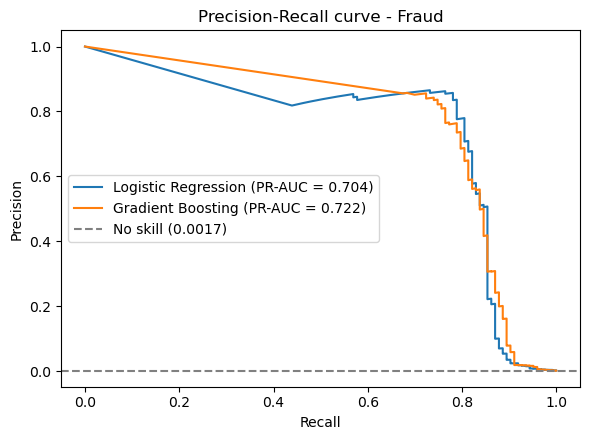

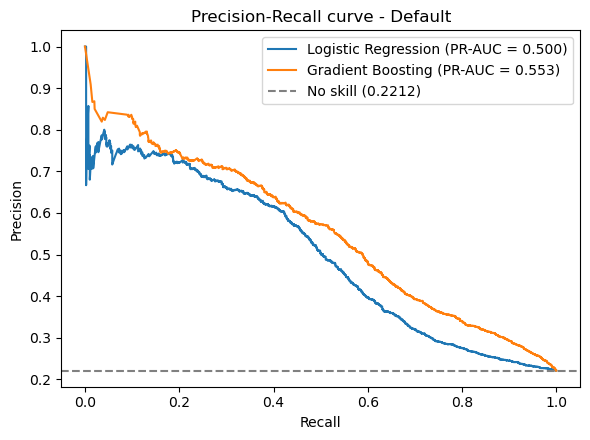

In [11]:
for dataset, pairs, y_test in [
    ("Fraud",   [("Logistic Regression", lr_fraud, Xf_test),
                 ("Gradient Boosting",   gb_fraud, Xf_test)], yf_test),
    ("Default", [("Logistic Regression", lr_default, Xd_test),
                 ("Gradient Boosting",   gb_default, Xd_test)], yd_test),
]:
    plt.figure(figsize=(6, 4.5))
    for name, model, X_test in pairs:
        proba = model.predict_proba(X_test)[:, 1]
        p, r, _ = precision_recall_curve(y_test, proba)
        ap = average_precision_score(y_test, proba)
        plt.plot(r, p, label=f"{name} (PR-AUC = {ap:.3f})")
    plt.axhline(y_test.mean(), ls="--", c="grey",
                label=f"No skill ({y_test.mean():.4f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Precision-Recall curve - {dataset}")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"pr_curve_{dataset.lower()}.png", dpi=150)
    plt.show()

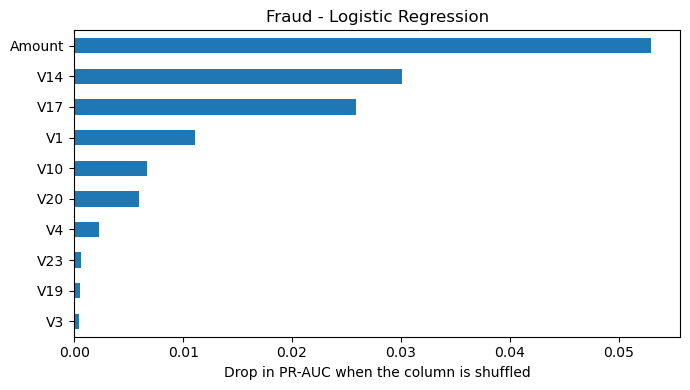

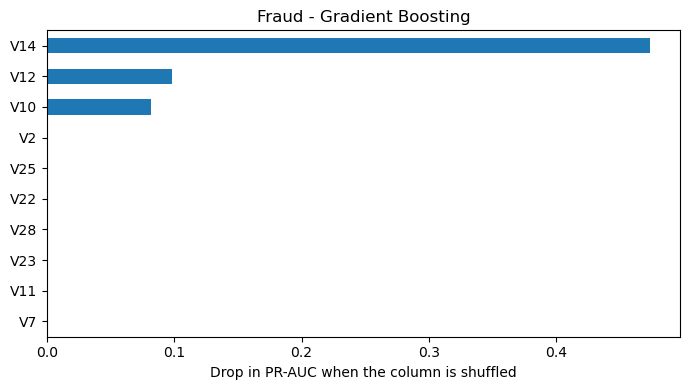

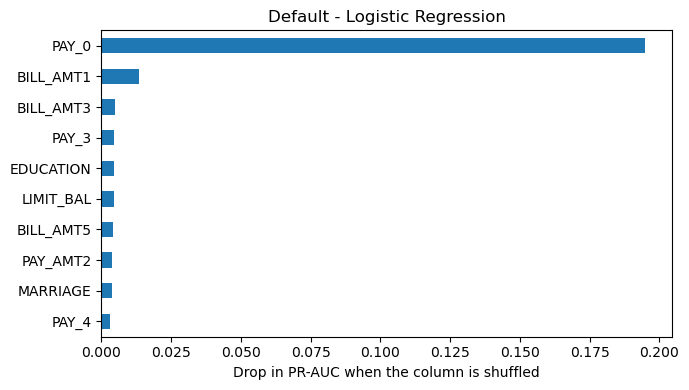

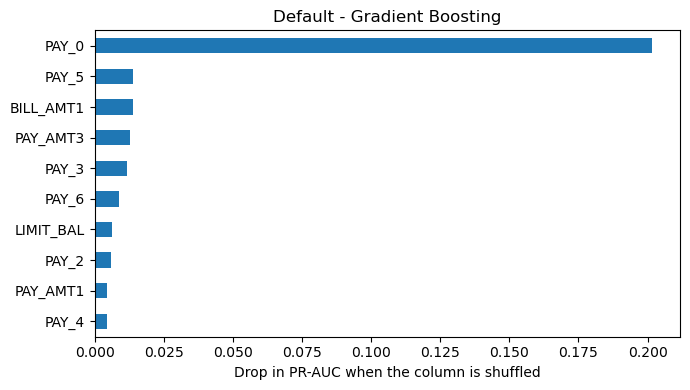

In [12]:
def top_features(model, X_test, y_test, title, n=10, sample=5000):
    if len(X_test) > sample:
        X_test = X_test.sample(sample, random_state=RANDOM_STATE)
        y_test = y_test.loc[X_test.index]
    r = permutation_importance(model, X_test, y_test, n_repeats=5,
                               scoring="average_precision",
                               random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

    plt.figure(figsize=(7, 4))
    imp.head(n)[::-1].plot(kind="barh")
    plt.xlabel("Drop in PR-AUC when the column is shuffled")
    plt.title(title); plt.tight_layout()
    plt.savefig(f"importance_{title.replace(' ', '_').replace('-', '')}.png", dpi=150)
    plt.show()
    return imp.head(n)

imp_lr_f = top_features(lr_fraud,   Xf_test, yf_test, "Fraud - Logistic Regression")
imp_gb_f = top_features(gb_fraud,   Xf_test, yf_test, "Fraud - Gradient Boosting")
imp_lr_d = top_features(lr_default, Xd_test, yd_test, "Default - Logistic Regression")
imp_gb_d = top_features(gb_default, Xd_test, yd_test, "Default - Gradient Boosting")

In [13]:
summary = results[["dataset", "model", "accuracy", "precision", "recall",
                   "f1", "roc_auc", "pr_auc", "no_skill"]].round(4)
summary.to_csv("results_summary.csv", index=False)

print(summary.to_string(index=False))
print()
print("Lift over the no-skill baseline (PR-AUC divided by baseline):")
for _, row in summary.iterrows():
    print(f"  {row['dataset']:<8} {row['model']:<20} {row['pr_auc']/row['no_skill']:>7.1f}x")

dataset               model  accuracy  precision  recall     f1  roc_auc  pr_auc  no_skill
  Fraud Logistic Regression    0.9761     0.0607  0.8862 0.1136   0.9727  0.7036    0.0017
  Fraud   Gradient Boosting    0.9961     0.2884  0.8699 0.4332   0.9710  0.7217    0.0017
Default Logistic Regression    0.6796     0.3688  0.6305 0.4654   0.7162  0.4998    0.2212
Default   Gradient Boosting    0.7525     0.4566  0.6251 0.5277   0.7776  0.5526    0.2212

Lift over the no-skill baseline (PR-AUC divided by baseline):
  Fraud    Logistic Regression    413.9x
  Fraud    Gradient Boosting      424.5x
  Default  Logistic Regression      2.3x
  Default  Gradient Boosting        2.5x
